### KNEIGHBORS CLASSIFIER MODELING

The cleaned dataset from exploratory data analysis is loaded.

The features and target variable are defined and split into train and test sets.

Synthetic Minority Oversampling Technique for Nominal and Continuous features (**SMOTE-NC**) addresses the class imbalance.

Features are scaled and encoded as required during preprocessing.

A pipeline is used and model parameters are optimized using **GridSearchCV**.     

**Classification report** and **confusion matrix** are used to verify the accuracy, precision, and recall as well as display the **true negatives**, **false positives**, **false negatives**, and **true positives**.   

**Costs** and **savings** are defined to support the **profit_loss_analysis**.   

The **thresholds** are tuned to optimize the profits.  
    
**Feature importance** is ranked and further analyzed using **SHAP**.    

The model **performance metrics**, **feature importances**, and **SHAP** importances are output and compared with other models in a models summary notebook.

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.     


**Import the required libraries**

In [97]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

In [98]:
# Load the dataset
df = pd.read_csv('cleaned_data_ccp.csv')

In [99]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [100]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [101]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction',
 'avg_monthly_usage',
 'charge_increase',
 'is_new_customer',
 'is_loyal_customer',
 'activity_ratio',
 'usage_trend',
 'auto_payment',
 'negative_customer',
 'no_referrals',
 'has_referrals',
 'high_referral_customer',
 'high_escalations',
 'referral_tenure',
 'loyal_monthly_customer',
 'tickets_support',
 'is_happy_customer',
 'not_happy_customer',
 'high_fee_customer',
 'budget_customer',
 'high_risk_flags1',
 'high_risk_flags2',
 'high_risk_flags5',
 'high_risk_flags6',
 'high_risk_flags7',
 'high_risk_flags8',
 'high_risk_flags9',
 'high_risk_flags10',
 'high_risk_flags11',
 'high_risk_flags12',
 'high_risk_

In [102]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = [col for col in numerical_columns if col != 'churn']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 117 numeric columns.


In [103]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'features_used',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response',
 'tenure_group']

In [104]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response','customer_segment']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 3 ordinal columns and 10 nominal columns.


In [105]:
# Verify 'contract_type', 'survey_response', and 'customer_segment'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts(), '\n')
print(df['customer_segment'].value_counts())

contract_type
Monthly      4967
Quarterly    3050
Yearly       1983
Name: count, dtype: int64 

survey_response
Satisfied      4975
Neutral        2978
Unsatisfied    2047
Name: count, dtype: int64 

customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64


In [106]:
# Define ordinal categories
ordinal_categories=[
  ['Monthly','Quarterly','Yearly'],          # contract_type
  ['Unsatisfied','Neutral','Satisfied'],     # survey_response
  ['Individual','SME','Enterprise']          # customer_segment
]

In [107]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop=None, handle_unknown="ignore"), nominal_cols),
    ],
    remainder=StandardScaler()
)

In [108]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel',
                                                   'features_used',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type',
                                                   'tenure_group'])])),
                ('knn', KNeighborsClassifier())])

In [109]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 90.71%
The test accuracy of the model is 88.45%


In [110]:
# Generate classification report
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1796
           1       0.32      0.11      0.17       204

    accuracy                           0.88      2000
   macro avg       0.61      0.54      0.55      2000
weighted avg       0.85      0.88      0.86      2000



The model does not catch churners effectively (recall = 0.11 for the positive class).
   
**Synthetic Minority Oversampling Technique for Nominal and Continuous features (SMOTE-NC)**     
In order to address the class imbalance, SMOTE-NC is used.

**SMOTE-NC** tries to overcome the machine learning bias towards the majority class by creating entirely new and synthetic samples which are similar to the samples that are already in the train dataset.

In [111]:
# Prepare data for SMOTE-NC
preprocessor = ColumnTransformer(transformers=[
    ('ord', Pipeline([
        ('enc', OrdinalEncoder(categories=ordinal_categories)),
        ('scaler', StandardScaler())
    ]), ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('num', StandardScaler(), numeric_cols)
])

In [112]:
# Verify number of categorical features

print(f'There are {len(ordinal_cols)} ordinal features and {len(nominal_cols)} nominal features.')

There are 3 ordinal features and 10 nominal features.


In [113]:
# Prepare SMOTE-NC
cat_indices = list(range(0,13))
smote_step = SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=2)

In [114]:
# Assemble the pipeline
from imblearn.pipeline import Pipeline

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_step),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied'],
                                                                                              ['Individual',
                                                                                               'SME',
                                                                                               'Enterprise']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown...
                                                   'avg_monthly_usage',
                                                   'charge_increase',
                                                   'is_new_customer',
                                                   'is_loyal_customer',
                                                   'activity_ratio',
                                                   'usage_trend',
                                                   'auto_payment',
                                                   'negative_customer',
                                                   'no_referrals',
                                                   'has_referrals',
                                                   'high_referral_customer', ...])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12],
                         k_neighbors=2, random_state=42)),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [115]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 100.00%
The test accuracy of the model is 66.80%


The overfit model is optimized.

In [116]:
# Set up parameter grid
param_grid = {
    'knn__n_neighbors': [40, 50, 60, 70, 80],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [117]:
# Run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='f1',
    error_score='raise'
)
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ord',
                                                                         Pipeline(steps=[('enc',
                                                                                          OrdinalEncoder(categories=[['Monthly',
                                                                                                                      'Quarterly',
                                                                                                                      'Yearly'],
                                                                                                                     ['Unsatisfied',
                                                                                                                      'Neutral',
                                                                                                                      'Satisfied'],
                                                                                                                     ['Individual',
                                                                                                                      'SME',
                                                                                                                      'Enterprise']])),
                                                                                         ('scaler',
                                                                                          Standard...
                                                                          'no_referrals',
                                                                          'has_referrals',
                                                                          'high_referral_customer', ...])])),
                                       ('smote',
                                        SMOTENC(categorical_features=[0, 1, 2,
                                                                      3, 4, 5,
                                                                      6, 7, 8,
                                                                      9, 10, 11,
                                                                      12],
                                                k_neighbors=2,
                                                random_state=42)),
                                       ('knn',
                                        KNeighborsClassifier(weights='distance'))]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [40, 50, 60, 70, 80],
                         'knn__weights': ['uniform']},
             scoring='f1')

In [118]:
# Verify the best parameters

print(f'Best parameters: {grid_knn.best_params_}')
print(f'Best score: {grid_knn.best_score_:.4f}')

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 80, 'knn__weights': 'uniform'}
Best score: 0.3621


In [119]:
# Access the optimized pipeline model
best_model = grid_knn.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied'],
                                                                                              ['Individual',
                                                                                               'SME',
                                                                                               'Enterprise']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown...
                                                   'charge_increase',
                                                   'is_new_customer',
                                                   'is_loyal_customer',
                                                   'activity_ratio',
                                                   'usage_trend',
                                                   'auto_payment',
                                                   'negative_customer',
                                                   'no_referrals',
                                                   'has_referrals',
                                                   'high_referral_customer', ...])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12],
                         k_neighbors=2, random_state=42)),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=80))])

In [120]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 77.86%
The test accuracy of the model is 76.70%


In [121]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86      1796
           1       0.25      0.63      0.36       204

    accuracy                           0.77      2000
   macro avg       0.60      0.71      0.61      2000
weighted avg       0.88      0.77      0.81      2000



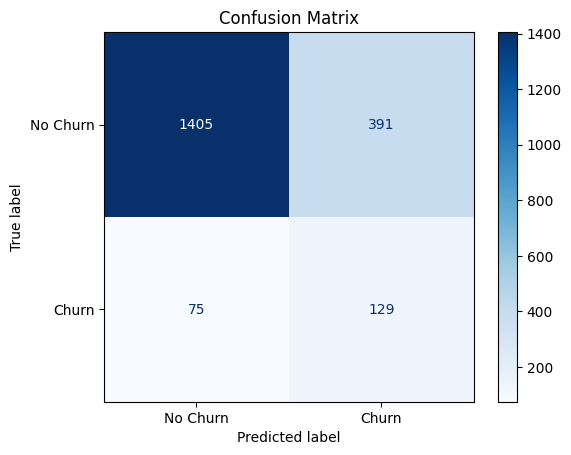

In [122]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [123]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 391 
 fn: 75 
 tp: 129 
 tn: 1405


In [124]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.77
Precision: 0.25
Recall: 0.63
---------------


In [125]:
# Calculate f2 score
beta = 2
f2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.4828


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [126]:
# Profit/loss analysis
L=500
C=40
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $6,200


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

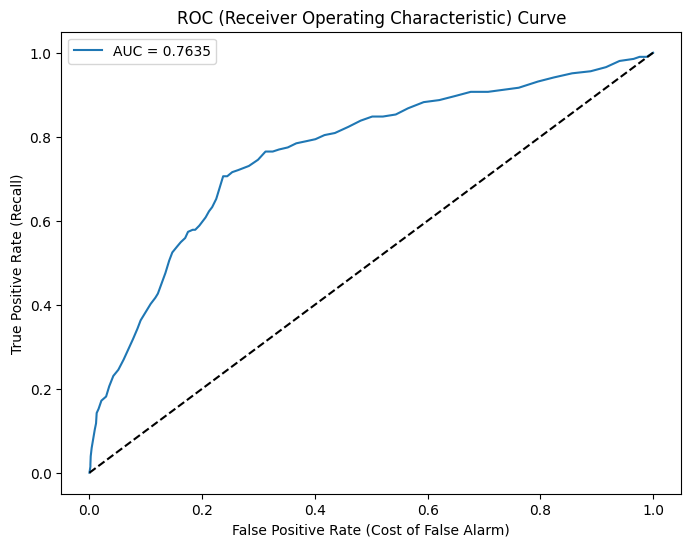

In [127]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [128]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.4750


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [129]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

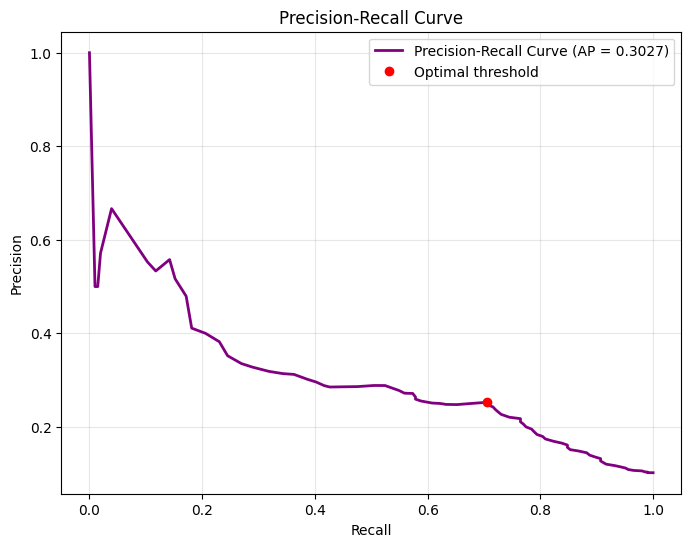

In [130]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [131]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.25, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.10 | Recall=1.00
Threshold=0.01 | Precision=0.10 | Recall=0.99
Threshold=0.02 | Precision=0.10 | Recall=0.99
Threshold=0.03 | Precision=0.10 | Recall=0.99
Threshold=0.04 | Precision=0.11 | Recall=0.98
Threshold=0.05 | Precision=0.11 | Recall=0.98
Threshold=0.06 | Precision=0.11 | Recall=0.97
Threshold=0.07 | Precision=0.11 | Recall=0.96
Threshold=0.08 | Precision=0.11 | Recall=0.95
Threshold=0.09 | Precision=0.11 | Recall=0.94
Threshold=0.10 | Precision=0.11 | Recall=0.94
Threshold=0.11 | Precision=0.12 | Recall=0.93
Threshold=0.12 | Precision=0.12 | Recall=0.92
Threshold=0.13 | Precision=0.12 | Recall=0.91
Threshold=0.14 | Precision=0.13 | Recall=0.91
Threshold=0.15 | Precision=0.13 | Recall=0.91
Threshold=0.16 | Precision=0.13 | Recall=0.91
Threshold=0.17 | Precision=0.14 | Recall=0.90
Threshold=0.18 | Precision=0.14 | Recall=0.89
Threshold=0.19 | Precision=0.14 | Recall=0.88
Threshold=0.20 | Precision=0.14 | Recall=0.88
Threshold=0.21 | Precision=0.15 | 

In [132]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.19


In [133]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [134]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.41      0.57      1796
           1       0.14      0.88      0.25       204

    accuracy                           0.46      2000
   macro avg       0.56      0.64      0.41      2000
weighted avg       0.88      0.46      0.54      2000



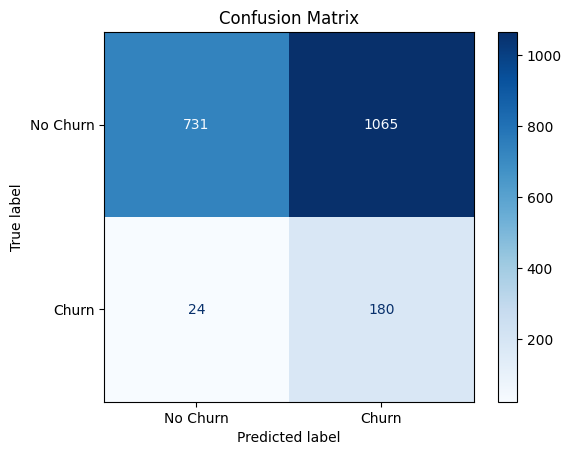

In [135]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [136]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 1065 
 fn: 24 
 tp: 180 
 tn: 731


In [137]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.46
Precision: 0.14
Recall: 0.88
---------------


In [138]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.4367


In [139]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $28,200


**Feature Selection**

In [140]:
# Verify number of features
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(f'The number of transformed features is {len(feature_names)}')

The number of transformed features is 157


In [141]:
# Determine the best number of features
results = []
feature_counts = [90, 110, 130, 157]
# Transform
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

for k in feature_counts:
    # Selector
    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=k
    )
    # Feature selection
    X_train_selected = selector.fit_transform(
        X_train_trans,
        y_train
    )
    X_test_selected = selector.transform(
        X_test_trans
    )
    # Final model
    model = KNeighborsClassifier(n_neighbors=5, weights='distance')
    model.fit(X_train_selected, y_train)
    # Predictions
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    # Metrics
    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    auc = roc_auc_score(y_test, y_proba)
    # Store results
    results.append({
        "num_features": k,
        "accuracy": accuracy,
        "recall": recall,
        "f1": f1,
        "auc": auc
    })
    # Selected features
    feature_names = preprocessor.get_feature_names_out()
    selected_features = feature_names[
      selector.get_support()
    ]

    print(f"\nTop {k} Features:")
    print(selected_features.tolist())

# Summary table
results_df = pd.DataFrame(results)

print("\nPerformance Summary:")
print(results_df)


Top 90 Features:
['ord__customer_segment', 'nom__gender_Male', 'nom__country_Australia', 'nom__country_Germany', 'nom__country_India', 'nom__country_UK', 'nom__country_USA', 'nom__city_Berlin', 'nom__city_Dhaka', 'nom__city_London', 'nom__signup_channel_Referral', 'nom__payment_method_Card', 'nom__payment_method_PayPal', 'nom__discount_applied_No', 'nom__complaint_type_Billing', 'nom__tenure_group_(0, 4]', 'nom__tenure_group_(24, 36]', 'nom__tenure_group_(36, 52]', 'nom__tenure_group_(4, 24]', 'num__tenure_months', 'num__monthly_logins', 'num__avg_session_time', 'num__total_revenue', 'num__payment_failures', 'num__csat_score', 'num__escalations', 'num__nps_score', 'num__tenure_fee_interaction', 'num__avg_monthly_usage', 'num__charge_increase', 'num__is_new_customer', 'num__is_loyal_customer', 'num__activity_ratio', 'num__usage_trend', 'num__negative_customer', 'num__no_referrals', 'num__high_referral_customer', 'num__high_escalations', 'num__referral_tenure', 'num__loyal_monthly_custo

Choose 90 features (the performance difference is slight compared to the significant noise reduction).

In [142]:
# Define final selector
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=90
)

In [143]:
# Build pipeline
from imblearn.pipeline import Pipeline

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_step),
    ('selector', selector),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied'],
                                                                                              ['Individual',
                                                                                               'SME',
                                                                                               'Enterprise']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown...
                                                   'usage_trend',
                                                   'auto_payment',
                                                   'negative_customer',
                                                   'no_referrals',
                                                   'has_referrals',
                                                   'high_referral_customer', ...])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12],
                         k_neighbors=2, random_state=42)),
                ('selector',
                 SelectKBest(k=90,
                             score_func=<function mutual_info_classif at 0x7f9bd209b4c0>)),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [144]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 100.00%
The test accuracy of the model is 69.20%


In [145]:
# Set up parameter grid
param_grid = {
    'knn__n_neighbors': [40, 50, 60, 70, 80],
    'knn__weights': ['uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [146]:
# Run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='f1',
    error_score='raise'
)
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ord',
                                                                         Pipeline(steps=[('enc',
                                                                                          OrdinalEncoder(categories=[['Monthly',
                                                                                                                      'Quarterly',
                                                                                                                      'Yearly'],
                                                                                                                     ['Unsatisfied',
                                                                                                                      'Neutral',
                                                                                                                      'Satisfied'],
                                                                                                                     ['Individual',
                                                                                                                      'SME',
                                                                                                                      'Enterprise']])),
                                                                                         ('scaler',
                                                                                          Standard...
                                        SMOTENC(categorical_features=[0, 1, 2,
                                                                      3, 4, 5,
                                                                      6, 7, 8,
                                                                      9, 10, 11,
                                                                      12],
                                                k_neighbors=2,
                                                random_state=42)),
                                       ('selector',
                                        SelectKBest(k=90,
                                                    score_func=<function mutual_info_classif at 0x7f9bd209b4c0>)),
                                       ('knn',
                                        KNeighborsClassifier(weights='distance'))]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [40, 50, 60, 70, 80],
                         'knn__weights': ['uniform']},
             scoring='f1')

In [147]:
# Verify the best parameters and score

print(f'Best parameters: {grid_knn.best_params_}')
print(f'Best score: {grid_knn.best_score_:.4f}')

Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 70, 'knn__weights': 'uniform'}
Best score: 0.3596


In [148]:
# Access the optimized pipeline model
best_model = grid_knn.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('enc',
                                                                   OrdinalEncoder(categories=[['Monthly',
                                                                                               'Quarterly',
                                                                                               'Yearly'],
                                                                                              ['Unsatisfied',
                                                                                               'Neutral',
                                                                                               'Satisfied'],
                                                                                              ['Individual',
                                                                                               'SME',
                                                                                               'Enterprise']])),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown...
                                                   'auto_payment',
                                                   'negative_customer',
                                                   'no_referrals',
                                                   'has_referrals',
                                                   'high_referral_customer', ...])])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11, 12],
                         k_neighbors=2, random_state=42)),
                ('selector',
                 SelectKBest(k=90,
                             score_func=<function mutual_info_classif at 0x7f9bd209b4c0>)),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=70))])

In [149]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 77.68%
The test accuracy of the model is 76.55%


In [150]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86      1796
           1       0.25      0.67      0.37       204

    accuracy                           0.77      2000
   macro avg       0.60      0.72      0.61      2000
weighted avg       0.88      0.77      0.81      2000



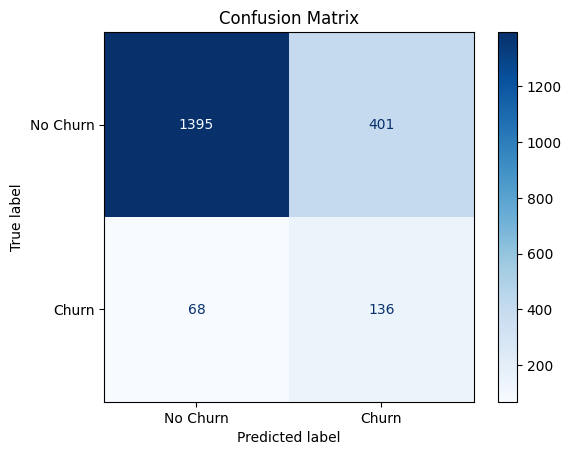

In [151]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [152]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 401 
 fn: 68 
 tp: 136 
 tn: 1395


In [153]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.77
Precision: 0.25
Recall: 0.67
---------------


In [154]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5026


In [155]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $12,520


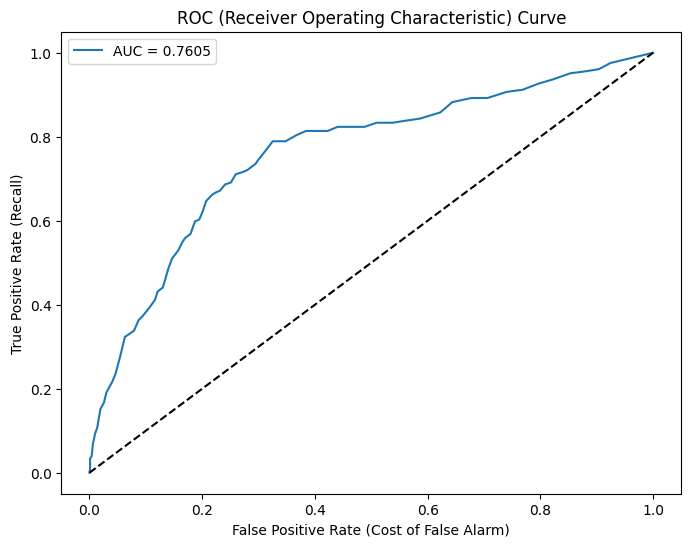

In [156]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [157]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.3714


In [158]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

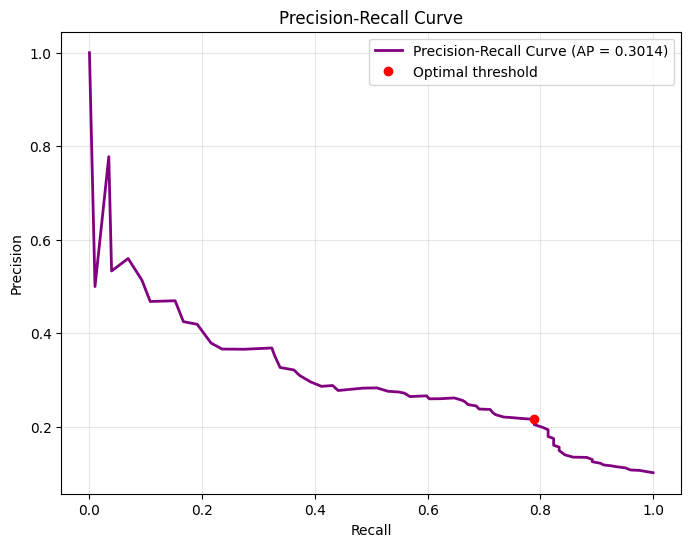

In [159]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [160]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.20, 0.40, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.20 | Precision=0.15 | Recall=0.84
Threshold=0.21 | Precision=0.15 | Recall=0.83
Threshold=0.22 | Precision=0.16 | Recall=0.83
Threshold=0.23 | Precision=0.16 | Recall=0.82
Threshold=0.24 | Precision=0.16 | Recall=0.82
Threshold=0.25 | Precision=0.17 | Recall=0.82
Threshold=0.26 | Precision=0.18 | Recall=0.82
Threshold=0.27 | Precision=0.18 | Recall=0.82
Threshold=0.28 | Precision=0.18 | Recall=0.81
Threshold=0.29 | Precision=0.19 | Recall=0.81
Threshold=0.30 | Precision=0.19 | Recall=0.81
Threshold=0.31 | Precision=0.19 | Recall=0.81
Threshold=0.32 | Precision=0.20 | Recall=0.80
Threshold=0.33 | Precision=0.20 | Recall=0.79
Threshold=0.34 | Precision=0.20 | Recall=0.79
Threshold=0.35 | Precision=0.21 | Recall=0.79
Threshold=0.36 | Precision=0.22 | Recall=0.79
Threshold=0.37 | Precision=0.22 | Recall=0.79
Threshold=0.38 | Precision=0.22 | Recall=0.76
Threshold=0.39 | Precision=0.22 | Recall=0.75


In [161]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.3000000000000001


In [162]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [163]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.62      0.75      1796
           1       0.19      0.81      0.31       204

    accuracy                           0.64      2000
   macro avg       0.58      0.71      0.53      2000
weighted avg       0.89      0.64      0.71      2000



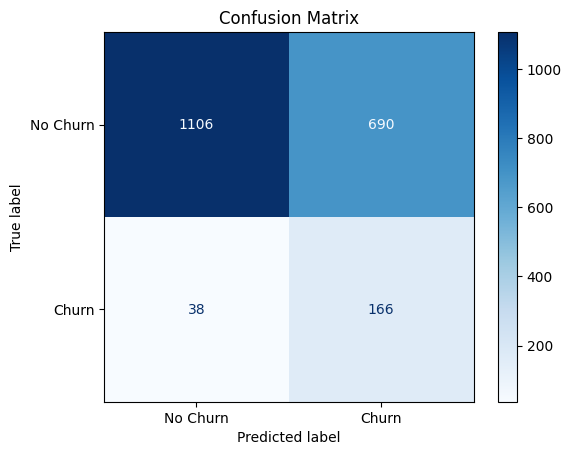

In [164]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [165]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 690 
 fn: 38 
 tp: 166 
 tn: 1106


In [166]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.64
Precision: 0.19
Recall: 0.81
---------------


In [167]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.4964


In [168]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $29,760


**Feature Importance**     


In [169]:
# Extract the fitted preprocessor and selector from the pipeline
fitted_preprocessor = pipe.named_steps['preprocessor']
fitted_selector = pipe.named_steps['selector']

In [170]:
# Get the feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature names

In [171]:
# Create a DataFrame of features and their Mutual Information scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': fitted_selector.scores_
})

In [172]:
# Sort by score in descending order
feature_importance_df = feature_importance_df.sort_values(by='Score', ascending=False).reset_index(drop=True)

In [173]:
# View the top 10 most important features

print(feature_importance_df.head(10))

                  Feature     Score
0                     age  0.476082
1         email_open_rate  0.467859
2    marketing_click_rate  0.465379
3       usage_growth_rate  0.458488
4               nps_score  0.445729
5          monthly_logins  0.441290
6           tenure_months  0.437889
7     last_login_days_ago  0.424116
8  tenure_fee_interaction  0.409116
9           total_revenue  0.409020


In [174]:
# Get a boolean mask of the selected features (True = kept, False = dropped)
#support_mask = fitted_selector.get_support()

# Filter the feature names using the mask
#selected_features = feature_names[support_mask]

#print(f"Number of features selected: {len(selected_features)}")
#print(selected_features)

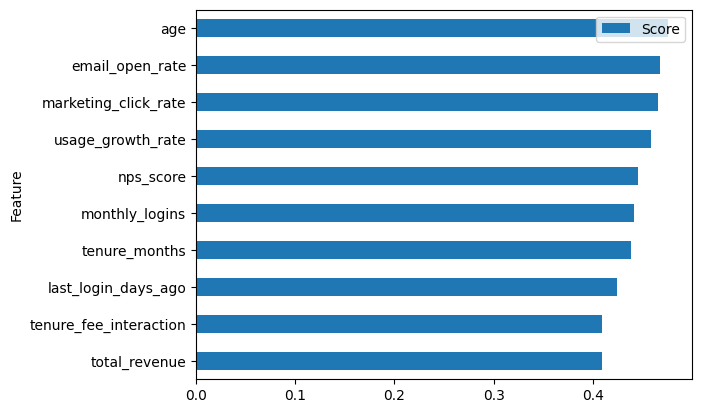

In [175]:
# Visualize
feature_importance_df.head(10).plot(
    x="Feature",
    y="Score",
    kind="barh"
)
plt.gca().invert_yaxis()
plt.show()

**SHAP Analysis**     

Unhappy customers are much more likely to churn.
Very strong and expected business signal.

Not happy customer with csat_score=2.0 is likely to churn.

Customers with low monthly logins are likely to churn.

Low csat_score is an indication of churn.

A happy customer is not churning.

In [176]:
# Slice the pipeline to get everything except the final KNN model
transformation_pipeline = best_model[:-1]

# Extract feature names from the fitted pipeline steps
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_selector = best_model.named_steps['selector']

all_feature_names = fitted_preprocessor.get_feature_names_out()
selected_feature_names = all_feature_names[fitted_selector.get_support()]
selected_feature_names = [i.split('__')[-1] for i in selected_feature_names]  # clean names

# Transform X_train
X_train_transformed = transformation_pipeline.transform(X_train)
X_train_selected_df = pd.DataFrame(
    X_train_transformed, columns=selected_feature_names, index=X_train.index
)

# Transform X_test
X_test_transformed = transformation_pipeline.transform(X_test)
X_test_selected_df = pd.DataFrame(
    X_test_transformed, columns=selected_feature_names, index=X_test.index
)

PermutationExplainer explainer: 51it [15:18, 18.38s/it]


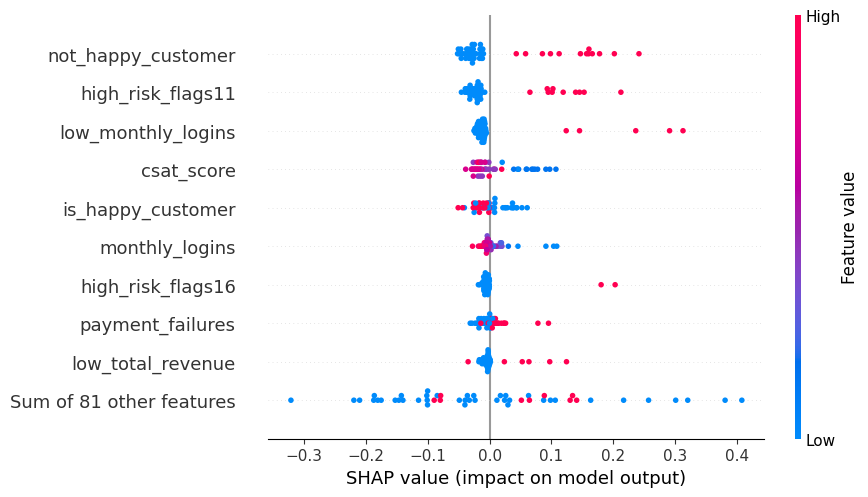

In [177]:
# Sample the dataframe directly
background_data = X_train_selected_df.sample(40, random_state=42)

# Initialize the generic Explainer
explainer = shap.Explainer(
    best_model.named_steps['knn'].predict_proba,
    background_data
)

# Take test sample and calculate the SHAP values
X_test_sample = X_test_selected_df.sample(50, random_state=42)
shap_values = explainer(X_test_sample)

# Plot the beeswarm chart for the churn class (Class 1)
shap.plots.beeswarm(shap_values[:, :, 1])

In [178]:
# Build dataframe
shap_importance = pd.DataFrame({
    "feature": X_train_selected_df.columns,
    "importance": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
})

# Sort by importance to see top churn drivers
shap_importance = shap_importance.sort_values(by="importance", ascending=False).reset_index(drop=True)

print(shap_importance.head(10))

              feature  importance
0  not_happy_customer    0.057864
1   high_risk_flags11    0.044248
2  low_monthly_logins    0.034485
3          csat_score    0.028957
4   is_happy_customer    0.019514
5      monthly_logins    0.014832
6   high_risk_flags16    0.013448
7    payment_failures    0.013181
8   low_total_revenue    0.012479
9   high_fee_customer    0.012136


**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [179]:
# Build dataframe
knn_model_df = pd.DataFrame({
    'Model': ['KNeighbors'],
    'AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F2_Score': [f2_score],
    'Profit_Loss': [profit_loss],
})
knn_model_df

,Model,AUC,Accuracy,Precision,Recall,F2_Score,Profit_Loss
0,KNeighbors,0.7605,0.636,0.1939,0.8137,0.4964,29760


In [180]:
# Output model performance
knn_model_df.to_csv("knn_metrics.csv", index=False)

In [181]:
# Output the features importance
feature_importance_df.to_csv("knn_features.csv", index=False)

In [182]:
# Output the SHAP importance
shap_importance.to_csv("knn_shap.csv", index=False)

**Sample Predictions**

In [183]:
# Obtain sample_1 from X_test
sample_1 = X_test.loc[[6563]]
proba_1 = best_model.predict_proba(sample_1)

print(f'The [[0, 1]] probabilities are {proba_1}')

The [[0, 1]] probabilities are [[0.72857143 0.27142857]]


In [184]:
# Verify actual churn

print("Actual churn:", y_test.loc[6563])

Actual churn: 1


In [185]:
# Predict a false negative
pred_1 = int(proba_1[:,1] >= best_threshold)

print("Predicted churn:", pred_1)

Predicted churn: 0


In [186]:
# Obtain sample_2 from X_test
sample_2 = X_test.loc[[4503]]
proba_2 = best_model.predict_proba(sample_2)

print(f'The [[0, 1]] probabilities are {proba_2}')

The [[0, 1]] probabilities are [[0.67142857 0.32857143]]


In [187]:
# Verify actual churn

print("Actual churn:", y_test.loc[4503])

Actual churn: 0


In [188]:
# Predict a false positive
pred_2 = int(proba_2[:,1] >= best_threshold)

print("Predicted churn:", pred_2)

Predicted churn: 1


In [189]:
# Obtain sample_3 from X_test
sample_3 = X_test.loc[[5978]]
proba_3 = best_model.predict_proba(sample_3)

print(f'The [[0, 1]] probabilities are {proba_3}')

The [[0, 1]] probabilities are [[0.58571429 0.41428571]]


In [190]:
# Verify actual churn

print("Actual churn:", y_test.loc[5978])

Actual churn: 1


In [191]:
# Predict a true positive
pred_3 = int(proba_3[:,1] >= best_threshold)

print("Predicted churn:", pred_3)

Predicted churn: 1
